# Dataset Preparation & Experimental Design

## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Load Dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine Work

In [3]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Remove missing value
df.dropna(inplace=True)

# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

## Experimental Design

The experiment follows a controlled simulation approach.

1. Start with the complete NDVI time series (ground truth).
2. Artificially remove a consecutive block of observations.
3. Reconstruct the missing values using Linear interpolation.
4. Compare reconstructed values with the original observations.
5. Calculate RMSE, MAE, and R².
6. Repeat the experiment for different gap lengths and multiple random locations.

This design isolates the effect of **temporal gap length** on reconstruction accuracy.

## Experiment Settings

In [4]:
gap_lengths = [
    2,
    4,
    6,
    8,
]

n_trials = 30

random_state = 42

np.random.seed(random_state)

## Define Evaluation Metrics

In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def mae(y_true, y_pred):
    return mean_absolute_error(
        y_true,
        y_pred
    )


# Artificial Temporal Gap Generation & Reconstruction

## Creating Artificial Temporal Gaps

In real satellite observations, missing data often occur as consecutive temporal gaps caused by cloud cover, rainfall, or quality filtering.

To evaluate interpolation methods objectively, we create artificial gaps by temporarily removing consecutive observations from the complete NDVI time series.

Because the original values are known, they can later be used as the **ground truth** for evaluating reconstruction accuracy.

##Function to Create Consecutive Gaps

In [6]:
def create_gap(df, gap_length):

    gap_df = df.copy()

    # Avoid beginning and end of the dataset
    start = np.random.randint(
        1,
        len(df) - gap_length - 1
    )

    missing_idx = gap_df.index[
        start:start + gap_length
    ]

    ground_truth = gap_df.loc[
        missing_idx
    ].copy()

    gap_df.loc[
        missing_idx,
        "NDVI"
    ] = np.nan

    return gap_df, ground_truth

## Example gap creation

In [7]:
gap_length = 4
analysis_df = df.copy()

gap_df, ground_truth = create_gap(
    analysis_df,
    gap_length
)

print(f"Gap Length : {gap_length} observations")

display(ground_truth)

Gap Length : 4 observations


,NDVI
date,
2024-12-04,0.196364
2024-12-14,0.265595
2024-12-24,0.342170
2024-12-29,0.372136


## Varify missing value

In [8]:
print("Missing values after gap creation")

gap_df.isna().sum()

Missing values after gap creation


,0
NDVI,4


## Ploting missing value

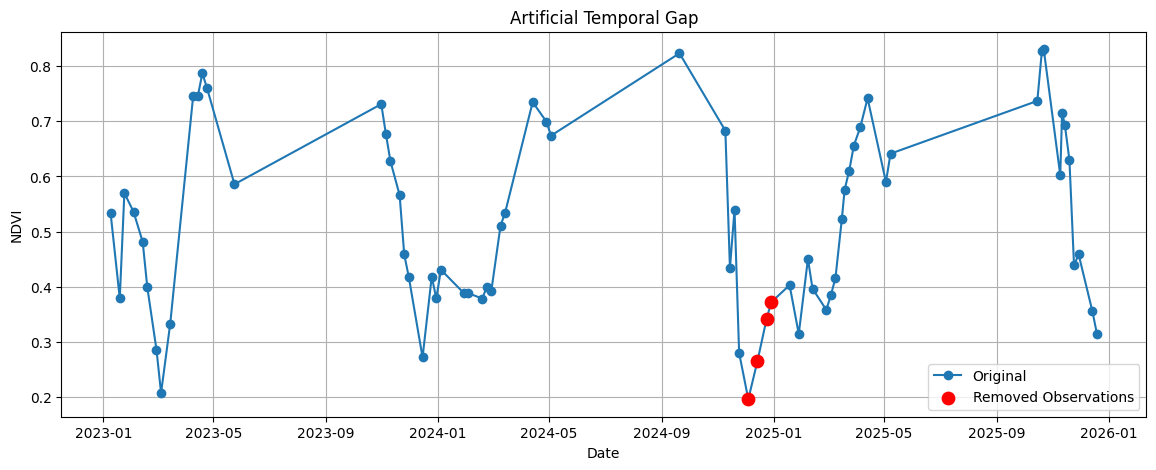

In [9]:
plt.figure(figsize=(14,5))

plt.plot(
    analysis_df.index,
    analysis_df["NDVI"],
    "-o",
    label="Original"
)

plt.scatter(
    ground_truth.index,
    ground_truth["NDVI"],
    color="red",
    s=80,
    label="Removed Observations",
    zorder=5
)

plt.title("Artificial Temporal Gap")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Perform Linear Interpolation

In [10]:
reconstructed_df = gap_df.copy()

reconstructed_df["NDVI"] = (
    reconstructed_df["NDVI"]
    .interpolate(
        method="linear"
    )
)

In [11]:
comparison = pd.DataFrame({

    "Date": ground_truth.index,

    "Original NDVI": ground_truth["NDVI"],

    "Interpolated NDVI":
        reconstructed_df.loc[
            ground_truth.index,
            "NDVI"
        ]

})

comparison

,Date,Original NDVI,Interpolated NDVI
date,,,
2024-12-04,2024-12-04,0.196364,0.305024
2024-12-14,2024-12-14,0.265595,0.329559
2024-12-24,2024-12-24,0.342170,0.354095
2024-12-29,2024-12-29,0.372136,0.378630


In [12]:
gap_start = ground_truth.index.min() - pd.Timedelta(days=30)
gap_end = ground_truth.index.max() + pd.Timedelta(days=30)

zoom = pd.concat(
    [
        analysis_df.loc[gap_start:gap_end],
        reconstructed_df.loc[gap_start:gap_end][["NDVI"]]
    ],
    axis=1
)

zoom.columns = [
    "Original",
    "Interpolated"
]

zoom.head()

,Original,Interpolated
date,,
2024-11-09,0.683078,0.683078
2024-11-14,0.433926,0.433926
2024-11-19,0.539918,0.539918
2024-11-24,0.280489,0.280489
2024-12-04,0.196364,0.305024


## Plot Zoomed Gap

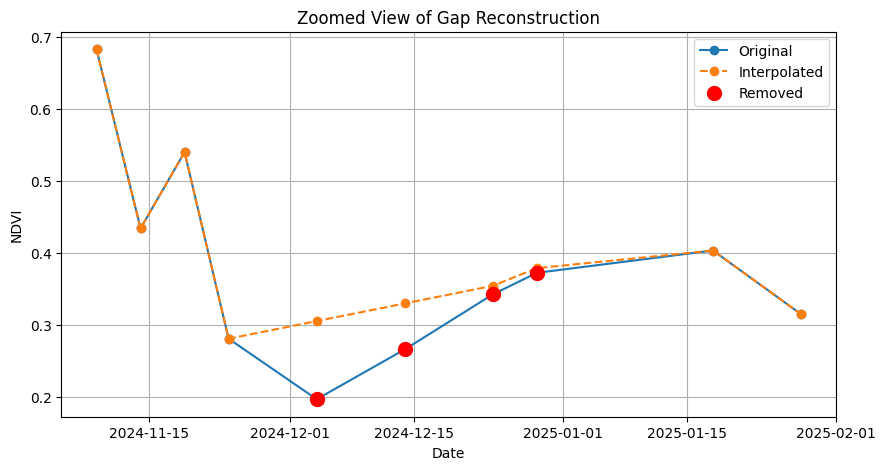

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    zoom.index,
    zoom["Original"],
    "-o",
    label="Original"
)

plt.plot(
    zoom.index,
    zoom["Interpolated"],
    "--o",
    label="Interpolated"
)

plt.scatter(
    ground_truth.index,
    ground_truth["NDVI"],
    color="red",
    s=100,
    zorder=5,
    label="Removed"
)

plt.title("Zoomed View of Gap Reconstruction")

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

# Temporal Gap Sensitivity Experiment

## Evaluation Function

In [14]:
def evaluate_interpolation(df, gap_length):
    """
    Create a gap, interpolate it, and evaluate reconstruction accuracy.
    """

    # Create artificial gap
    gap_df, ground_truth = create_gap(df, gap_length)

    # Linear interpolation
    reconstructed = gap_df.copy()

    reconstructed["NDVI"] = (
        reconstructed["NDVI"]
        .interpolate(method="linear")
    )

    # True vs predicted
    y_true = ground_truth["NDVI"]

    y_pred = reconstructed.loc[
        ground_truth.index,
        "NDVI"
    ]

    return {

        "RMSE": rmse(y_true, y_pred),

        "MAE": mae(y_true, y_pred)

    }

## Run the Experiment

In [15]:
results = []
analysis_df = df.copy()

for gap in gap_lengths:

    print(f"Gap Length = {gap}")

    for trial in range(n_trials):

        metrics = evaluate_interpolation(
            df=analysis_df,
            gap_length=gap
        )

        metrics["Gap Length"] = gap

        metrics["Trial"] = trial + 1

        results.append(metrics)

Gap Length = 2
Gap Length = 4
Gap Length = 6
Gap Length = 8


## Results DataFrame

In [16]:
results_df = pd.DataFrame(results)

display(results_df)

,RMSE,MAE,Gap Length,Trial
0,0.003863,0.003801,2,1
1,0.004495,0.003729,2,2
2,0.130208,0.103051,2,3
3,0.065974,0.047098,2,4
4,0.018443,0.016341,2,5
...,...,...,...,...
115,0.251384,0.224033,8,26
116,0.251384,0.224033,8,27
117,0.142262,0.123540,8,28
118,0.125094,0.105613,8,29


## Summary Table

In [17]:
summary_mean = (

    results_df

    .groupby("Gap Length")

    [["RMSE", "MAE"]]

    .mean()

    .reset_index()

)

summary_mean = summary_mean.round(4)

display(summary_mean)

,Gap Length,RMSE,MAE
0,2,0.0672,0.0612
1,4,0.1096,0.0995
2,6,0.1272,0.1127
3,8,0.1494,0.1299


R² < 0

Your interpolation is actually worse than predicting the mean.

## RMSE vs Gap Length

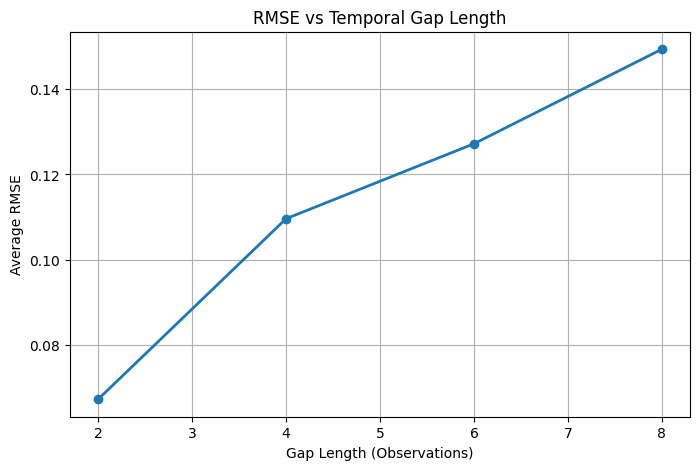

In [18]:
plt.figure(figsize=(8,5))

plt.plot(

    summary_mean["Gap Length"],

    summary_mean["RMSE"],

    "-o",

    linewidth=2

)

plt.title("RMSE vs Temporal Gap Length")

plt.xlabel("Gap Length (Observations)")

plt.ylabel("Average RMSE")

plt.grid(True)

plt.show()